In [1]:
import torch
import torch.nn as nn
from models.multimodalAttention import *
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from data.datamodule import DataModuleTemporal
import torchvision
import tqdm

/users/eleves-b/2023/keyvan.attarian/MODAL/venv/lib64/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))
/users/eleves-b/2023/keyvan.attarian/MODAL/venv/lib64/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dict = torch.load("checkpoints/MIN_ATT&DAR_MULTIMODAL_2025-05-25_10-35-48.pt",weights_only=False)

In [6]:
for k in dict["model_state_dict"].keys():
    print(k)

min_year
max_year
image_encoder.lsh_proj
image_encoder.backbone.cls_token
image_encoder.backbone.pos_embed
image_encoder.backbone.register_tokens
image_encoder.backbone.mask_token
image_encoder.backbone.patch_embed.proj.weight
image_encoder.backbone.patch_embed.proj.bias
image_encoder.backbone.blocks.0.norm1.weight
image_encoder.backbone.blocks.0.norm1.bias
image_encoder.backbone.blocks.0.attn.qkv.weight
image_encoder.backbone.blocks.0.attn.qkv.bias
image_encoder.backbone.blocks.0.attn.proj.weight
image_encoder.backbone.blocks.0.attn.proj.bias
image_encoder.backbone.blocks.0.ls1.gamma
image_encoder.backbone.blocks.0.norm2.weight
image_encoder.backbone.blocks.0.norm2.bias
image_encoder.backbone.blocks.0.mlp.fc1.weight
image_encoder.backbone.blocks.0.mlp.fc1.bias
image_encoder.backbone.blocks.0.mlp.fc2.weight
image_encoder.backbone.blocks.0.mlp.fc2.bias
image_encoder.backbone.blocks.0.ls2.gamma
image_encoder.backbone.blocks.1.norm1.weight
image_encoder.backbone.blocks.1.norm1.bias
image_

In [12]:
dict["model_state_dict"]["cross_attn.in_proj_weight"].size()


torch.Size([2304, 768])

In [13]:
3*768

2304

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [2]:
!export HF_HOME=/Data/

In [3]:
import os
os.environ["HF_HOME"] = "/Data/"

In [4]:
os.environ.get("HF_HOME")

'/Data/'

In [9]:
model = MultiModalAttentionRegressor()
regressor = torch.load("/Data/checkpoints/ATT&DAR_MULTIMODAL_2025-05-26_19-53-48.pt",weights_only=False)["model_state_dict"]
model.load_state_dict(regressor, strict=False)
model.eval()
model.to(device)

Loading checkpoint shards: 100%|██████████| 2/2 [00:04<00:00,  2.44s/it]


shape of image encoder:  2048
shape of text encoder:  2048
shape of channel embedding:  8


MultiModalAttentionRegressor(
  (image_encoder): ResNet50(
    (backbone): Sequential(
      (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (4): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): 

In [ ]:
from models.resnet import ResNet50
from models.llama import LlamaTextEncoder
img_model = ResNet50()
text_model = LlamaTextEncoder()
img_model.to(device)
text_model.to(device)

Loading checkpoint shards:   0%|          | 0/2 [00:02<?, ?it/s]


OutOfMemoryError: CUDA out of memory. Tried to allocate 86.00 MiB. GPU 0 has a total capacity of 23.54 GiB of which 23.25 MiB is free. Including non-PyTorch memory, this process has 23.36 GiB memory in use. Of the allocated memory 22.73 GiB is allocated by PyTorch, and 440.09 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [11]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((224, 224)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
datamodule = DataModuleTemporal(
    dataset_path="dataset/",
    train_transform=transform,
    test_transform=transform,
    batch_size=256,
    num_workers=8,
    taille_val=0.2,
)
val_loader = datamodule.val_dataloader()

dataset//train_val.csv
Entrainement temporalisé
Pourcentage des données utilisées pour la validation : 19.51%
dataset//train_val.csv
Utilisation des indices fournis pour créer les ensembles d'entraînement et de validation.


In [ ]:
loss_fn = nn.MSELoss()

In [12]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"


In [ ]:
epoch_val_loss = 0
num_samples_val = 0
all_targets = []
all_dino = []
all_bert = []

for _, batch in enumerate(tqdm.tqdm(val_loader, desc="Validating")):
    batch["image"] = batch["image"].to(device)
    batch["target"] = batch["target"].to(device).squeeze()
    batch["channel"] = batch["channel"].to(device)
    batch["year"] = batch["year"].to(device)
    with torch.no_grad():
        img_embd = img(batch)
        text_embd = text(batch)
    # Collect for scatter plot
    all_targets.append(batch["target"].detach().cpu().numpy())
    all_dino.append(dino_pred.detach().cpu().numpy())


# After validation loop, scatter predictions vs target
all_dino = np.concatenate(all_dino)

Validating: 100%|██████████| 12/12 [06:36<00:00, 33.06s/it]


ValueError: zero-dimensional arrays cannot be concatenated

In [ ]:
all_dino.shape

(3021, 768)

In [ ]:
test_loader = datamodule.test_dataloader()

dataset//test.csv


In [ ]:
epoch_val_loss = 0
num_samples_val = 0
all_dino_test = []

for _, batch in enumerate(tqdm.tqdm(test_loader, desc="Validating")):
    with torch.no_grad():
        dino_pred = dino(batch)
    # Collect for scatter plot
    all_dino_test.append(dino_pred.detach().cpu().numpy())


# After validation loop, scatter predictions vs target
all_dino_test = np.concatenate(all_dino_test)


Validating: 100%|██████████| 3402/3402 [09:05<00:00,  6.24it/s]


In [ ]:
epoch_val_loss = 0
num_samples_val = 0
model.eval()
all_targets = []
all_preds = []
all_losses = []
all_channels = []

for _, batch in enumerate(tqdm.tqdm(val_loader, desc="Validating")):
    batch["image"] = batch["image"].to(device)
    batch["target"] = batch["target"].to(device).squeeze()
    batch["channel"] = batch["channel"].to(device)
    batch["year"] = batch["year"].to(device)
    with torch.no_grad():
        preds = dino(batch)
    loss = nn.functional.mse_loss(preds, batch["target"], reduction='none')  # shape: (batch_size,)
    # Collect for scatter plot
    all_targets.append(batch["target"].detach().cpu().numpy())
    all_preds.append(preds.detach().cpu().numpy())
    all_losses.append(loss.detach().cpu().numpy())
    all_channels.append(batch["channel"].detach().cpu().numpy())


# After validation loop, scatter predictions vs target
all_targets = np.concatenate(all_targets)
all_preds = np.concatenate(all_preds)
all_losses = np.concatenate(all_losses)
all_channels = np.concatenate(all_channels)
print(all_losses.mean())

Validating: 100%|██████████| 12/12 [00:49<00:00,  4.09s/it]

3.4847586


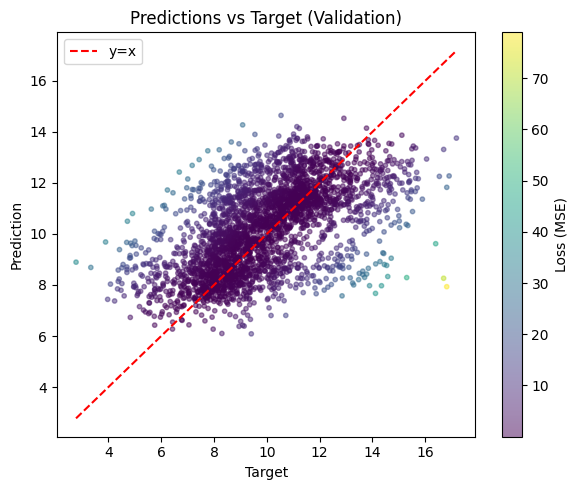

In [ ]:

# Plot 1: Predictions vs Target
plt.figure(figsize=(6, 5))
plt.scatter(all_targets, all_preds, alpha=0.5,c=all_losses, cmap='viridis', s=10)
plt.plot([all_targets.min(), all_targets.max()], [all_targets.min(), all_targets.max()], 'r--', label='y=x')
plt.legend()
plt.xlabel("Target")
plt.ylabel("Prediction")
plt.title("Predictions vs Target (Validation)")
plt.colorbar(label="Loss (MSE)")
plt.tight_layout()
plt.show()
plt.close()

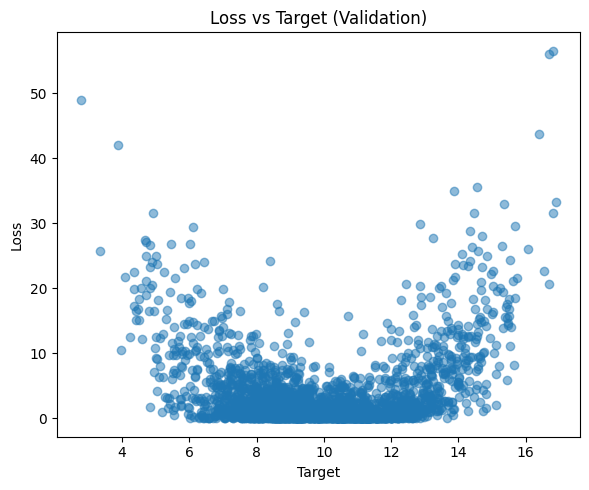

In [ ]:
# Plot 2: Loss vs Target
plt.figure(figsize=(6, 5))
plt.scatter(all_targets, all_losses, alpha=0.5)
plt.xlabel("Target")
plt.ylabel("Loss")
plt.title("Loss vs Target (Validation)")
plt.tight_layout()
plt.show()
plt.close()

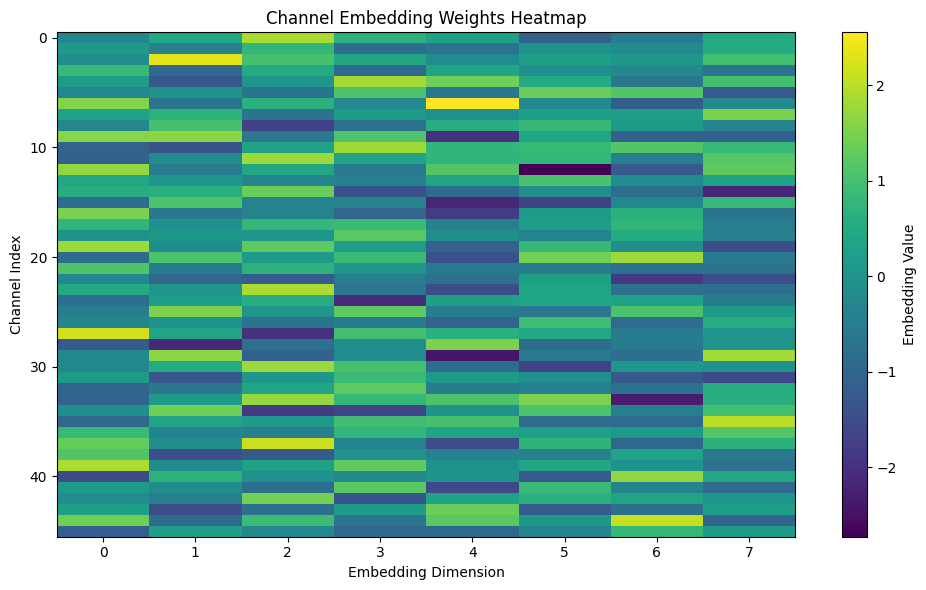

In [ ]:
plt.figure(figsize=(10, 6))
plt.imshow(emb_weights, aspect='auto', cmap='viridis')
plt.colorbar(label='Embedding Value')
plt.xlabel('Embedding Dimension')
plt.ylabel('Channel Index')
plt.title('Channel Embedding Weights Heatmap')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# Replace channel id in all_channels by its corresponding PCA embedding value
# all_channels shape: (N, 1), emb_pca shape: (46, 1)
all_channels_pca = emb_pca[all_channels.flatten()].flatten()
all_channels_pca

array([-0.7862933 , -0.1913054 , -0.7681456 , ..., -1.4517386 ,
        0.17606413, -1.4870467 ], dtype=float32)

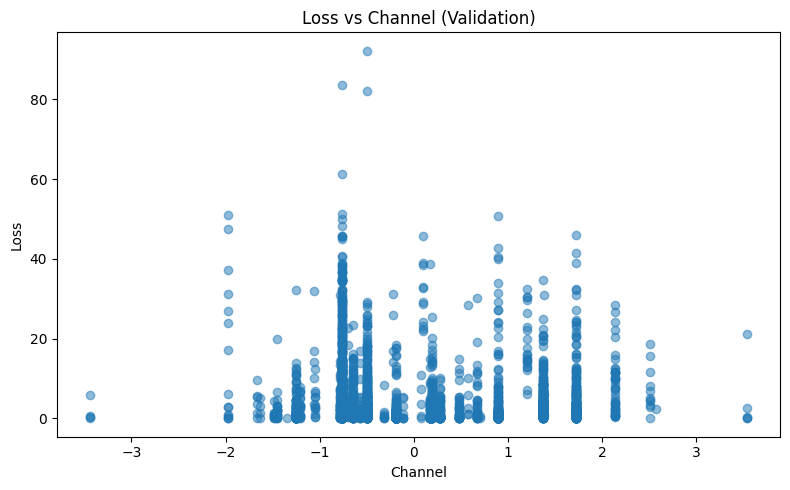

In [ ]:
# Concatenate all_channels into a flat numpy array

plt.figure(figsize=(8, 5))
plt.scatter(all_channels_pca, all_losses, alpha=0.5)
plt.xlabel("Channel")
plt.ylabel("Loss")
plt.title("Loss vs Channel (Validation)")
plt.tight_layout()
plt.show()
plt.close()

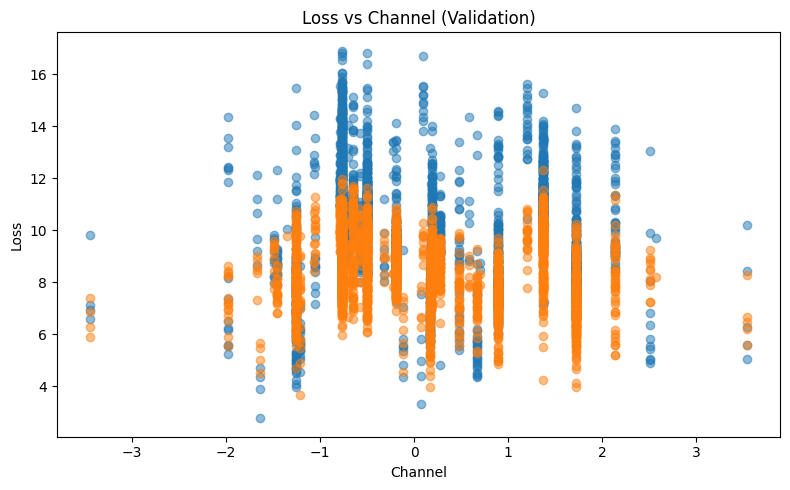

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(all_channels_pca, all_targets, alpha=0.5)
plt.scatter(all_channels_pca, all_preds, alpha=0.5)
plt.xlabel("Channel")
plt.ylabel("Loss")
plt.title("Loss vs Channel (Validation)")
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# Sélectionner les indices où la cible (log1p_views) < 10
mask = all_targets < 10

# Calculer la loss moyenne sur ces vidéos
mean_loss_under_10 = all_losses[mask].mean()
print(f"Loss moyenne pour log1p_views < 10 : {mean_loss_under_10:.4f}")
# Sélectionner les indices où la cible (log1p_views) < 10
mask = all_targets > 10

# Calculer la loss moyenne sur ces vidéos
mean_loss_under_10 = all_losses[mask].mean()
print(f"Loss moyenne pour log1p_views < 10 : {mean_loss_under_10:.4f}")

Loss moyenne pour log1p_views < 10 : 1.6411
Loss moyenne pour log1p_views < 10 : 8.8380


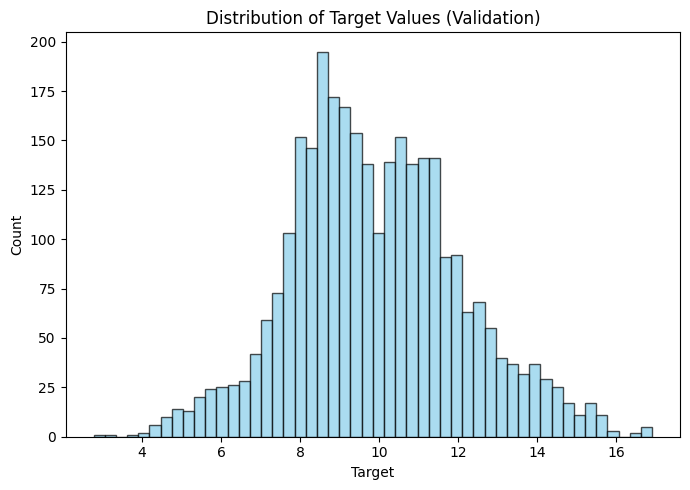

In [ ]:
plt.figure(figsize=(7, 5))
plt.hist(all_targets, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
plt.xlabel("Target")
plt.ylabel("Count")
plt.title("Distribution of Target Values (Validation)")
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
len(content_test)

NameError: name 'content_test' is not defined

In [ ]:
all_residus_dino = all_dino - all_dino.mean(axis=0)

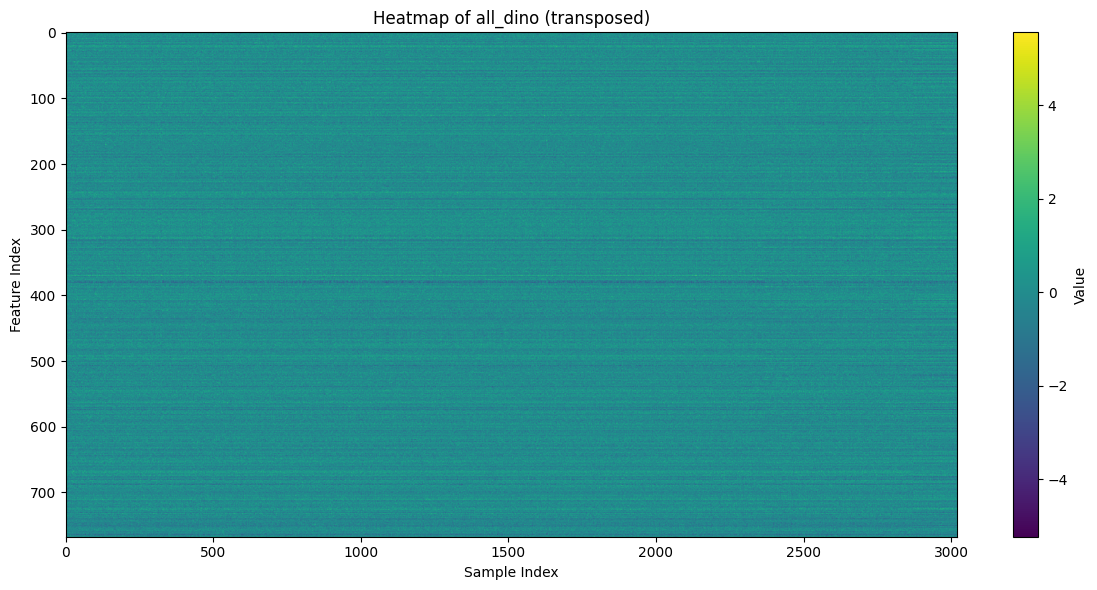

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(all_dino.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.xlabel('Sample Index')
plt.ylabel('Feature Index')
plt.title('Heatmap of all_dino (transposed)')
plt.tight_layout()
plt.show()
plt.close()

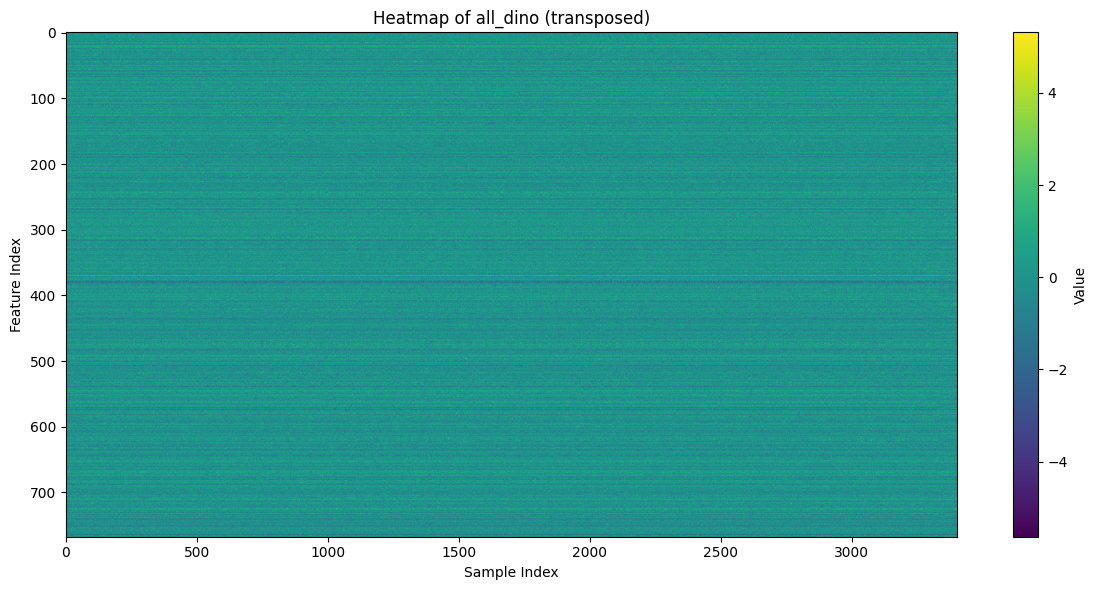

In [ ]:
plt.figure(figsize=(12, 6))
plt.imshow(all_dino_test.T, aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.xlabel('Sample Index')
plt.ylabel('Feature Index')
plt.title('Heatmap of all_dino (transposed)')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
from sklearn.decomposition import PCA

# PCA sur all_dino
pca = PCA(n_components=2)
all_dino_pca = pca.fit_transform(all_dino)

# PCA sur all_dino_test (utilise la même transformation)
all_dino_test_pca = pca.transform(all_dino_test)

print("all_dino_pca shape:", all_dino_pca.shape)
print("all_dino_test_pca shape:", all_dino_test_pca.shape)

all_dino_pca shape: (3021, 2)
all_dino_test_pca shape: (3402, 2)


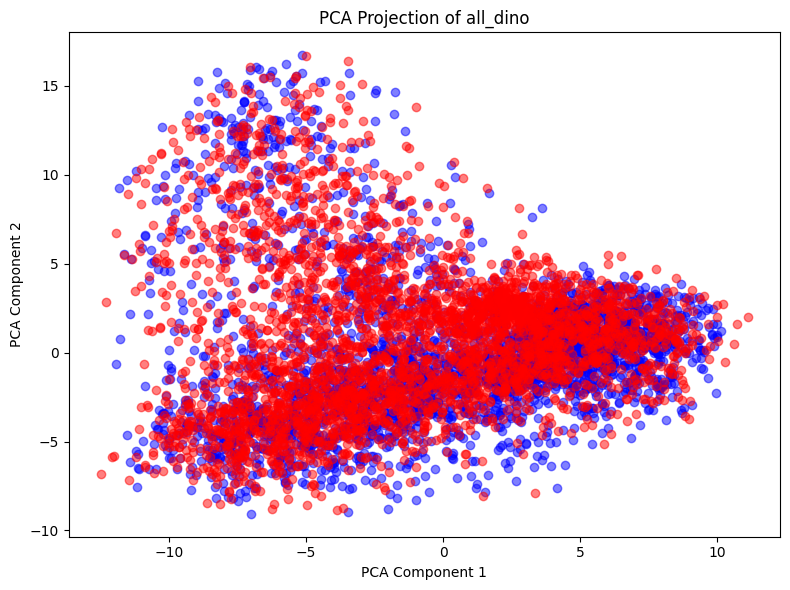

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(all_dino_pca[:, 0], all_dino_pca[:, 1], alpha=0.5, color='blue', label='Validation Data')
plt.scatter(all_dino_test_pca[:, 0], all_dino_test_pca[:, 1], alpha=0.5, color='red', label='Test Data')
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection of all_dino")
plt.tight_layout()
plt.show()
plt.close()

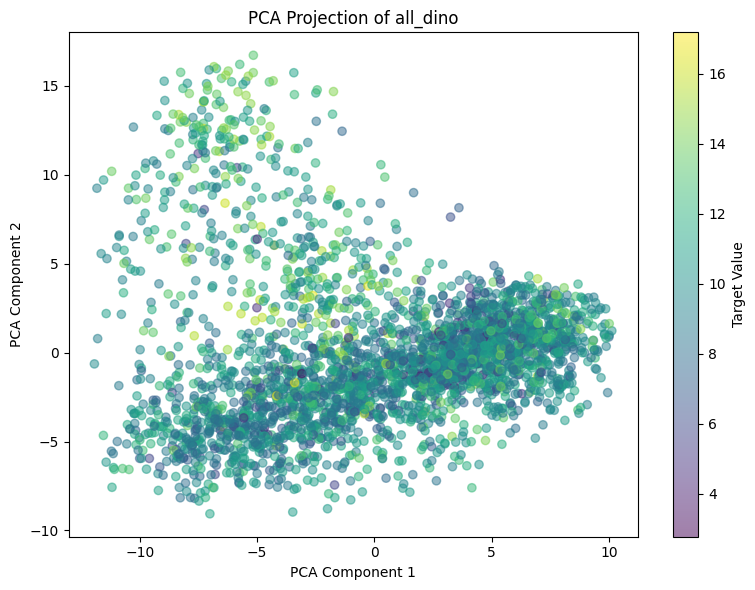

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(all_dino_pca[:, 0], all_dino_pca[:, 1], alpha=0.5, c=all_targets, label='Validation Data')
plt.colorbar(label="Target Value")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Projection of all_dino")
plt.tight_layout()
plt.show()
plt.close()